# 🚌 EDA Bizkaibus — Análisis de Viajeros 2020-2025

**Fuente:** [Open Data Bizkaia](https://www.opendatabizkaia.eus/es/catalogo/bizkaibus)  
**Período:** Enero 2020 – Diciembre 2025  
**Archivos:** 18 CSVs (2 semestrales por año en 2020-2022, 4 trimestrales por año en 2023-2025)  
**Granularidad:** una fila = una línea en un mes concreto


## 🎯 Hipótesis de Partida

<style>
.hipo-wrap {
  display: flex;
  gap: 24px;
  align-items: stretch;
  flex-wrap: wrap;
}

.hipo-text {
  flex: 1 1 460px;
  min-width: 280px;
}

.hipo-photo {
  flex: 1 1 320px;
  min-width: 260px;
  display: flex;
  align-items: center;
  justify-content: center;
}

.hipo-photo img {
  width: 100%;
  max-width: 460px;
  height: auto;
  object-fit: cover;
  border-radius: 14px;
  box-shadow: 0 8px 24px rgba(0,0,0,0.12);
}

.hipo-card {
  border: 1px solid #d0d7de;
  border-radius: 10px;
  padding: 10px 12px;
  margin-bottom: 10px;
  background: #f8fafc;
}

.hipo-card b {
  color: #0f172a;
}

@media (max-width: 900px) {
  .hipo-wrap {
    flex-direction: column;
  }

  .hipo-photo img {
    max-width: 100%;
  }
}
</style>

<div class="hipo-wrap">
  <div class="hipo-text">
    <div class="hipo-card"><b>H1:</b> Los títulos bonificados para jóvenes representan una proporción significativa del total de viajeros.</div>
    <div class="hipo-card"><b>H2:</b> Hay meses con más afluencia que otros (estacionalidad notable).</div>
    <div class="hipo-card"><b>H3:</b> Las líneas que conectan con Bilbao son las más saturadas (más viajeros por expedición).</div>
    <div class="hipo-card"><b>H4:</b> Las ayudas al transporte han impulsado el uso del autobús.</div>
  </div>

  <div class="hipo-photo">
    <img src="file:///C:/Users/rns_2/.cursor/projects/c-Users-rns-2-Desktop/assets/c__Users_rns_2_AppData_Roaming_Cursor_User_workspaceStorage_76f16690f72069c993dfa56c531e7358_images_de_la_diligencia_al_bizkaibus-232_page-0001-fbb1bf2d-e103-4f93-9ad0-4ea514413ad8.png" alt="De la diligencia al Bizkaibus">
  </div>
</div>


## 0. Imports y Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MESES_ES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}


## 1. Carga y Unión de Datasets

Cargamos los 18 archivos CSV con `glob` y los concatenamos en un único DataFrame.  
Añadimos `archivo_origen` para trazabilidad durante la limpieza.


In [3]:
junio_2020= pd.read_csv("data/bizkaibus/2020_biz_jun.csv")
dic_2020= pd.read_csv("data/bizkaibus/2020_biz_dic.csv")
junio_2021= pd.read_csv("data/bizkaibus/2021_biz_jun.csv")
dic_2021= pd.read_csv("data/bizkaibus/2021_biz_dic.csv")
junio_2022= pd.read_csv("data/bizkaibus/2022_biz_jun.csv")
dic_2022= pd.read_csv("data/bizkaibus/2022_biz_dic.csv")
marzo_2023= pd.read_csv("data/bizkaibus/2023_biz_mar.csv")
junio_2023= pd.read_csv("data/bizkaibus/2023_biz_jun.csv")
sept_2023= pd.read_csv("data/bizkaibus/2023_biz_sept.csv")
dic_2023= pd.read_csv("data/bizkaibus/2023_biz_dic.csv")
marzo_2024= pd.read_csv("data/bizkaibus/2024_biz_mar.csv")
junio_2024= pd.read_csv("data/bizkaibus/2024_biz_jun.csv")
sept_2024= pd.read_csv("data/bizkaibus/2024_biz_sept.csv")
dic_2024= pd.read_csv("data/bizkaibus/2024_biz_dic.csv")
marzo_2025= pd.read_csv("data/bizkaibus/2025_biz_mar.csv")
junio_2025= pd.read_csv("data/bizkaibus/2025_biz_jun.csv")
sept_2025= pd.read_csv("data/bizkaibus/2025_biz_sept.csv")
dic_2025= pd.read_csv("data/bizkaibus/2025_biz_dic.csv")

In [4]:
bizkaibus = pd.concat([junio_2020, dic_2020, junio_2021, dic_2021, junio_2022, dic_2022, marzo_2023, junio_2023, sept_2023, dic_2023,
                       marzo_2024, junio_2024, sept_2024, dic_2024, marzo_2025, junio_2025, sept_2025, dic_2025], 
                      ignore_index=True)
bizkaibus.info()

<class 'pandas.DataFrame'>
RangeIndex: 6852 entries, 0 to 6851
Data columns (total 44 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   _id                                                             6852 non-null   int64  
 1   EKITALDIA/EJERCICIO                                             6852 non-null   int64  
 2   HILABETE/MES                                                    6852 non-null   int64  
 3   ZENBAKIA/CODIGO                                                 6852 non-null   str    
 4   LERROA/LINEA                                                    6852 non-null   str    
 5   CREDITRANS/CREDITRANS                                           6658 non-null   float64
 6   CREDITRANS F20/CREDITRANS F20                                   6405 non-null   float64
 7   CREDITRANS F50/CREDITRANS F50                                 

### 1.2 Carga de Expediciones Realizadas

Cargamos los datos de expediciones (frecuencia de servicio) de 2021 a 2025.  
Esto nos permitirá calcular la **saturación** de cada línea: cuántos viajeros hay por expedición.


In [5]:
expediciones = pd.concat([
    pd.read_csv("data/expediciones/expediciones-realizadas-2021.csv", encoding='utf-8-sig'),
    pd.read_csv("data/expediciones/expediciones-realizadas-2022.csv", encoding='utf-8-sig'),
    pd.read_csv("data/expediciones/expediciones-realizadas-2023.csv", encoding='utf-8-sig'),
    pd.read_csv("data/expediciones/expediciones-realizadas-2024.csv", encoding='utf-8-sig'),
    pd.read_csv("data/expediciones/expediciones-realizadas-2025.csv", encoding='utf-8-sig'),
], ignore_index=True)

# Renombrar columnas al mismo estilo
expediciones.columns = [c.split('/')[-1].strip().lower().replace(' ', '_')
                        for c in expediciones.columns]

# Nos quedamos solo con lo que necesitamos
expediciones = expediciones[['ejercicio', 'codigo_linea', 'linea', 'total_expediciones']]

# Total expediciones por línea y año (sumando todas las temporadas y tipos de día)
exp_anio = expediciones.groupby(['ejercicio', 'codigo_linea', 'linea'])['total_expediciones'].sum().reset_index()

print(f"Expediciones cargadas: {exp_anio.shape[0]} registros")
print(f"Años: {sorted(exp_anio['ejercicio'].unique())}")
exp_anio.head()


Expediciones cargadas: 526 registros
Años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,ejercicio,codigo_linea,linea,total_expediciones
0,2021,A0651,BILBAO - BALMASEDA,46167
1,2021,A0652,LANESTOSA - BALMASEDA,9946
2,2021,A0653,TRUCIOS TURTZIOZ - ARTZENTALES,8736
3,2021,A0654,BALMASEDA - Gurutzeta/Cruces - UPV/EHU,16222
4,2021,A2151,Areeta/Las Arenas - LARRABETZU,26274


In [6]:
bizkaibus

,_id,EKITALDIA/EJERCICIO,HILABETE/MES,ZENBAKIA/CODIGO,LERROA/LINEA,CREDITRANS/CREDITRANS,CREDITRANS F20/CREDITRANS F20,CREDITRANS F50/CREDITRANS F50,GIZATRANS/GIZATRANS,GIZATRANS 20/GIZATRANS 20,...,BORO/BORO,BORO F20/BORO F20,BORO F50/BORO F50,BAT/BAT,BAT F20/BAT F20,BAT F50/BAT F50,BAT BEREZI/BAT BEREZI,BAT BEREZI F20/BAT BEREZI F20,BAT BEREZI F50/BAT BEREZI F50,ITSU-MUPEN DOAKO GIDARILAGUN/ACOMPANANTE GRATIS INVIDENTE-PMRS
0,1,2020,1,A2610,GALDAKAO - UPV/EHU,4924.0,224.0,19.0,341.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2020,1,A2611,UGAO MIRABALLES - BASAURI - ETXEBARRI - UPV/EHU,2391.0,98.0,2.0,255.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2020,1,A3613,BILBAO - UGAO MIRABALLES - OROZKO,16755.0,318.0,136.0,10458.0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2020,1,A3622,BILBAO - BASAURI - Artunduaga - San Miguel -ZA...,5963.0,184.0,71.0,2579.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2020,1,A3631,BILBAO - GALDAKAO - LARRABETZU,22186.0,562.0,192.0,6899.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6847,279,2025,12,A3524,BERMEO - BAKIO,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6848,280,2025,12,A3527,BILBAO - MUNGIA - BERMEO (Por la autopista/tik),60562.0,1989.0,175.0,10126.0,56.0,...,4092.0,129.0,47.0,19.0,5.0,0.0,2.0,0.0,0.0,0.0
6849,281,2025,12,A3528,BERMEO - MUNGIA - DERIO - UPV/EHU,3140.0,158.0,31.0,265.0,17.0,...,112.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6850,284,2025,12,A3531,LEIOA-Hospital Urduliz Ospitalea - GATIKA -MUNGIA,10586.0,366.0,35.0,3283.0,5.0,...,1376.0,32.0,7.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Exploración Inicial

Vamos a ir viendo si el dataset se ha creado correctamente, por ejemplo si los años y meses estan bien y que líneas tenemos

In [7]:
bizkaibus['EKITALDIA/EJERCICIO'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

In [8]:
bizkaibus['HILABETE/MES'].unique()

array([ 1,  4,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12])

In [9]:
print(bizkaibus['LERROA/LINEA'].nunique())

104


In [10]:
# Resumen estadístico (top columnas por media)
bizkaibus.describe().T.sort_values('mean', ascending=False).head(15).round()


,count,mean,std,min,25%,50%,75%,max
GUZTIRA/TOTAL,6852.0,22000.0,24774.0,0.0,3616.0,13580.0,33415.0,159804.0
CREDITRANS/CREDITRANS,6658.0,14327.0,15022.0,0.0,2712.0,9357.0,22396.0,85327.0
GIZATRANS/GIZATRANS,6574.0,3446.0,4246.0,0.0,308.0,1768.0,5077.0,27947.0
EKITALDIA/EJERCICIO,6852.0,2022.0,2.0,2020.0,2021.0,2022.0,2024.0,2025.0
BORO/BORO,2250.0,1121.0,1646.0,0.0,73.0,546.0,1463.0,14427.0
OHIKOA/OCASIONAL,6703.0,1117.0,4129.0,0.0,52.0,353.0,1160.0,71335.0
GAZTE 70/GAZTE 70,6282.0,954.0,1146.0,-2908.0,121.0,570.0,1360.0,10900.0
GORO/GORO,6271.0,857.0,1124.0,-2164.0,129.0,471.0,1150.0,10064.0
B 50/B 50,2250.0,760.0,947.0,0.0,58.0,458.0,1134.0,9998.0
CREDITRANS F20/CREDITRANS F20,6405.0,476.0,499.0,0.0,100.0,333.0,683.0,3693.0


## 3. Limpieza

### 3.1 Renombrado de Columnas

Los nombres originales tienen el formato `EUSKERA/CASTELLANO`.  
Extraemos la parte en castellano y convertimos a `snake_case`.


In [11]:
bizkaibus.columns = [
    col.split('/')[-1].lower().replace(' ', '_')
    for col in bizkaibus.columns]
bizkaibus.columns


Index(['_id', 'ejercicio', 'mes', 'codigo', 'linea', 'creditrans',
       'creditrans_f20', 'creditrans_f50', 'gizatrans', 'gizatrans_20',
       'gizatrans_50', 'bbcard_24', 'bbcard_48', 'bbcard_72', 'gazte_70',
       'gazte_70_f20', 'gazte_70_f50', 'goro', 'goro_f20', 'goro_f50',
       'ocasional', 'familia_numerosa', 'menores_de_6_anos',
       'acompanante_invidente-pmrs', 'metro', 'pup_averiado', 'empresa',
       'total', 'b_50', 'b50_f20', 'b50_f50', 'b70', 'b70_f20', 'b70_f50',
       'boro', 'boro_f20', 'boro_f50', 'bat', 'bat_f20', 'bat_f50',
       'bat_berezi', 'bat_berezi_f20', 'bat_berezi_f50',
       'acompanante_gratis_invidente-pmrs'],
      dtype='str')

### 3.2 Consolidación de Títulos de Transporte

Agrupamos las variantes F20/F50 y los sub-tipos de BBCard en columnas únicas según el perfil del viajero:

| Columna final | Componentes | Perfil |
|---|---|---|
| `creditrans` | creditrans + creditrans_f20 + creditrans_f50 | Adultos (título general) |
| `gizatrans` | gizatrans + gizatrans_20 + gizatrans_50 | Mayores 65+ |
| `bbcard` | bbcard_24 + bbcard_48 + bbcard_72 | Turistas |
| `gazte_70` | gazte_70 + gazte_70_f20 + gazte_70_f50 | Jóvenes <26, bono 70 viajes |
| `goro` | goro + goro_f20 + goro_f50 | Jóvenes <26, bono ilimitado |
| `b50` | b_50 + b50_f20 + b50_f50 | Adultos 26-65, 50 viajes *(desde 2024)* |
| `b70` | b70 + b70_f20 + b70_f50 | Adultos 26-65, 70 viajes *(desde 2024)* |
| `boro` | boro + boro_f20 + boro_f50 | Adultos 26-65, ilimitado *(desde 2024)* |
| `bat` | bat + bat_f20 + … + bat_berezi_f50 | Tarjeta Álava *(desde 2025)* |

> **Nota:** Las columnas de nuevos títulos (B50, B70, BORO, BAT) no existen en los archivos anteriores a 2024/2025.  
> Al concatenar, pandas las genera como `NaN` → las rellenamos con `0` antes de consolidar.


In [12]:
# Rellenar NaN con 0 en columnas de viajeros (títulos inexistentes en años anteriores)
cols_no_numericas = ['_id', 'ejercicio', 'mes', 'codigo', 'linea']
cols_viajeros_raw = [c for c in bizkaibus.columns if c not in cols_no_numericas]
bizkaibus[cols_viajeros_raw] = bizkaibus[cols_viajeros_raw].fillna(0)

# Función auxiliar: suma solo las columnas que existen en el DataFrame
def sumar_cols(df, *cols):
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pd.Series(0, index=df.index)
    return df[existentes].sum(axis=1)

# ── Consolidación ─────────────────────────────────────────────
bizkaibus['creditrans'] = sumar_cols(bizkaibus, 'creditrans', 'creditrans_f20', 'creditrans_f50')
bizkaibus['gizatrans']  = sumar_cols(bizkaibus, 'gizatrans',  'gizatrans_20',   'gizatrans_50')
bizkaibus['bbcard']     = sumar_cols(bizkaibus, 'bbcard_24',  'bbcard_48',      'bbcard_72')
bizkaibus['gazte_70']   = sumar_cols(bizkaibus, 'gazte_70',   'gazte_70_f20',   'gazte_70_f50')
bizkaibus['goro']       = sumar_cols(bizkaibus, 'goro',       'goro_f20',       'goro_f50')
bizkaibus['b50']        = sumar_cols(bizkaibus, 'b_50',       'b50_f20',        'b50_f50')
bizkaibus['b70']        = sumar_cols(bizkaibus, 'b70',        'b70_f20',        'b70_f50')
bizkaibus['boro']       = sumar_cols(bizkaibus, 'boro',       'boro_f20',       'boro_f50')
bizkaibus['bat']        = sumar_cols(bizkaibus, 'bat',        'bat_f20',        'bat_f50',
                              'bat_berezi',  'bat_berezi_f20', 'bat_berezi_f50')

print("Consolidación completada ✓")


Consolidación completada ✓


### 3.3 Columnas Finales

Descartamos todas las sub-variantes ya consolidadas y las columnas no relevantes:
`metro`, `pup_averiado`, `empresa`, `menores_de_6_anos`, `acompanante_invidente`.


In [13]:
COLS_FINALES = [
    'ejercicio', 'mes', 'codigo', 'linea',
    'creditrans', 'gizatrans', 'bbcard',
    'gazte_70', 'goro',
    'b50', 'b70', 'boro', 'bat',
    'ocasional', 'familia_numerosa',
    'total'
]

bizkaibus = bizkaibus[COLS_FINALES].copy()
print(f"Shape final: {bizkaibus.shape}")
bizkaibus.head()


Shape final: (6852, 16)


,ejercicio,mes,codigo,linea,creditrans,gizatrans,bbcard,gazte_70,goro,b50,b70,boro,bat,ocasional,familia_numerosa,total
0,2020,1,A2610,GALDAKAO - UPV/EHU,5167.0,341.0,0.0,1962.0,462.0,0.0,0.0,0.0,0.0,292.0,0.0,8358.0
1,2020,1,A2611,UGAO MIRABALLES - BASAURI - ETXEBARRI - UPV/EHU,2491.0,255.0,0.0,759.0,302.0,0.0,0.0,0.0,0.0,143.0,0.0,4070.0
2,2020,1,A3613,BILBAO - UGAO MIRABALLES - OROZKO,17209.0,10479.0,0.0,956.0,846.0,0.0,0.0,0.0,0.0,2739.0,31.0,33506.0
3,2020,1,A3622,BILBAO - BASAURI - Artunduaga - San Miguel -ZA...,6218.0,2582.0,0.0,199.0,201.0,0.0,0.0,0.0,0.0,922.0,1.0,10616.0
4,2020,1,A3631,BILBAO - GALDAKAO - LARRABETZU,22940.0,6919.0,0.0,1428.0,941.0,0.0,0.0,0.0,0.0,2507.0,0.0,35924.0


### 3.4 Missing Values

In [14]:
nulos = bizkaibus.isnull().sum()
if nulos.sum() == 0:
    print("✅ No hay valores nulos en el DataFrame limpio.")
else:
    print("Valores nulos por columna:")
    print(nulos[nulos > 0])


✅ No hay valores nulos en el DataFrame limpio.


### 3.5 Duplicados

In [15]:
n_dup = bizkaibus.duplicated(subset=['ejercicio', 'mes', 'codigo']).sum()
if n_dup == 0:
    print("✅ No hay filas duplicadas (por año + mes + código de línea).")
else:
    print(f"⚠️  Filas duplicadas encontradas: {n_dup}")
    print(bizkaibus[bizkaibus.duplicated(subset=['ejercicio','mes','codigo'], keep=False)]
          .sort_values(['ejercicio','mes','codigo']).head(10))


✅ No hay filas duplicadas (por año + mes + código de línea).


### 3.6 Outliers

Usamos el método IQR sobre `total`. Las filas con `total == 0` son líneas inactivas ese período: las excluimos del cálculo pero las mantenemos en el DataFrame principal.


In [16]:
bizkaibus_activo_check = bizkaibus[bizkaibus['total'] > 0]

Q1 = bizkaibus_activo_check['total'].quantile(0.25)
Q3 = bizkaibus_activo_check['total'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = max(Q1 - 1.5 * IQR, 0)

outliers = bizkaibus_activo_check[
    (bizkaibus_activo_check['total'] < lim_inf) | (bizkaibus_activo_check['total'] > lim_sup)
]

print(f"Q1={Q1:,.0f} | Q3={Q3:,.0f} | IQR={IQR:,.0f}")
print(f"Límite inferior: {lim_inf:,.0f} | Límite superior: {lim_sup:,.0f}")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(bizkaibus_activo_check)*100:.1f}%)")
print()
print("Top 10 outliers (mayor total):")
print(outliers.nlargest(10, 'total')[['ejercicio','mes','codigo','linea','total']])


Q1=4,616 | Q3=34,528 | IQR=29,912
Límite inferior: 0 | Límite superior: 79,397
Outliers detectados: 233 (3.6%)

Top 10 outliers (mayor total):
      ejercicio  mes codigo                                   linea     total
6614       2025   10  A3136          BILBAO - BARAKALDO - SANTURTZI  159804.0
6806       2025   12  A3136          BILBAO - BARAKALDO - SANTURTZI  155847.0
6711       2025   11  A3136          BILBAO - BARAKALDO - SANTURTZI  152836.0
6519       2025    9  A3136          BILBAO - BARAKALDO - SANTURTZI  149772.0
6143       2025    5  A3136          BILBAO - BARAKALDO - SANTURTZI  149410.0
6141       2025    5  A3129  Lutxana - Gurutzeta/Cruces - SANTURTZI  146054.0
4179       2023    8  A3247            BILBAO-Aireportua/Aeropuerto  145608.0
6329       2025    7  A3136          BILBAO - BARAKALDO - SANTURTZI  144844.0
5003       2024    5  A3136          BILBAO - BARAKALDO - SANTURTZI  144555.0
5949       2025    3  A3136          BILBAO - BARAKALDO - SANTURTZI  144288.0

C:\Users\rns_2\AppData\Local\Temp\ipykernel_10640\3463620621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bizkaibus_activo_check, x='ejercicio', y='total', palette=palette)


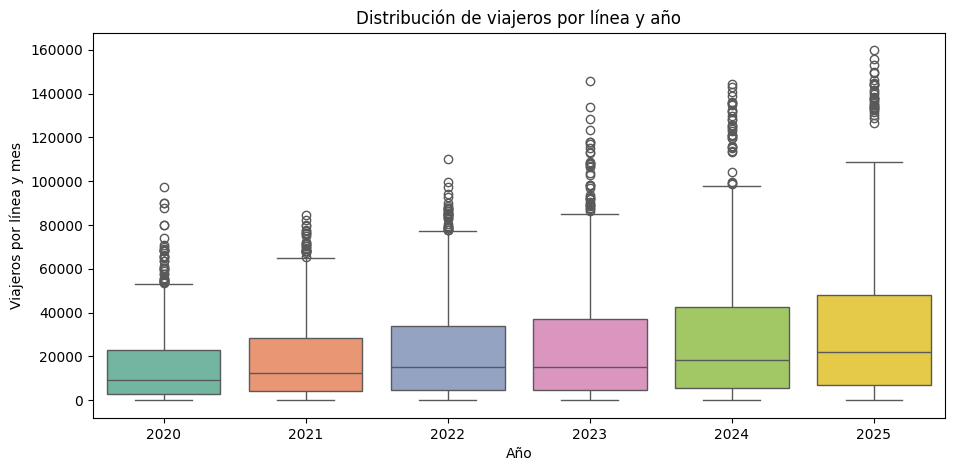

In [17]:
plt.figure(figsize=(11, 5))
palette = sns.color_palette('Set2', n_colors=bizkaibus_activo_check['ejercicio'].nunique())
sns.boxplot(data=bizkaibus_activo_check, x='ejercicio', y='total', palette=palette)
plt.title('Distribución de viajeros por línea y año')
plt.xlabel('Año')
plt.ylabel('Viajeros por línea y mes')
plt.show()


In [18]:
# Los outliers son líneas de alta frecuencia (troncales) → totalmente válidos.
# NO los eliminamos. Solo creamos bizkaibus_activo después de las transformaciones.
print(f"bizkaibus.shape: {bizkaibus.shape}  (incluye líneas con total=0)")


bizkaibus.shape: (6852, 16)  (incluye líneas con total=0)


## 4. Transformaciones

### 4.1 Columna de Fecha y Nombre de Mes

In [19]:
bizkaibus['fecha'] = pd.to_datetime(
    bizkaibus['ejercicio'].astype(str) + '-' + bizkaibus['mes'].astype(str).str.zfill(2) + '-01'
)

bizkaibus['mes_nombre'] = bizkaibus['mes'].map(MESES_ES)

print(f"Rango temporal del dataset:")
print(f"  · Inicio : {bizkaibus['fecha'].min().strftime('%B %Y')}")
print(f"  · Fin    : {bizkaibus['fecha'].max().strftime('%B %Y')}")
print(f"  · Períodos únicos: {bizkaibus['fecha'].nunique()}")



Rango temporal del dataset:
  · Inicio : January 2020
  · Fin    : December 2025
  · Períodos únicos: 72


### 4.2 Flag Pre / Post Subsidio

El **subsidio del 50%** en transporte público de Euskadi entró en vigor en **septiembre de 2022**.  
Usaremos esta fecha como punto de corte para el análisis de H4.


In [20]:
SUBSIDIO_INICIO = pd.Timestamp('2022-09-01')

bizkaibus['periodo_subsidio'] = bizkaibus['fecha'].apply(
    lambda x: 'Post-subsidio (>=Sep 2022)' if x >= SUBSIDIO_INICIO else 'Pre-subsidio (<Sep 2022)'
)

print("Meses por período:")
print(bizkaibus.groupby('periodo_subsidio')['fecha'].nunique().rename('n_meses'))


Meses por período:
periodo_subsidio
Post-subsidio (>=Sep 2022)    40
Pre-subsidio (<Sep 2022)      32
Name: n_meses, dtype: int64


### 4.3 Líneas que conectan con Bilbao


In [50]:
bizkaibus['conecta_bilbao'] = bizkaibus['linea'].str.upper().str.contains('BILBAO', na=False)

resumen_bilbao = bizkaibus.groupby('conecta_bilbao')['linea'].nunique()
print("Líneas únicas por flag:")
print(resumen_bilbao.rename({True: 'Conecta Bilbao', False: 'No conecta Bilbao'}))


Líneas únicas por flag:
conecta_bilbao
No conecta Bilbao    55
Conecta Bilbao       49
Name: linea, dtype: int64


### 4.4 Saturación de líneas


In [52]:
# Cruzamos viajeros con expediciones para calcular saturación (viajeros por expedición)
viajeros_linea = (bizkaibus_activo.groupby(['ejercicio', 'codigo'])['total']
                  .sum().reset_index()
                  .rename(columns={'codigo': 'codigo_linea'}))

saturacion = viajeros_linea.merge(exp_anio, on=['ejercicio', 'codigo_linea'])
saturacion['viajeros_por_exp'] = saturacion['total'] / saturacion['total_expediciones']
saturacion['conecta_bilbao'] = saturacion['linea'].str.upper().str.contains('BILBAO', na=False)

print(f"Registros en saturacion: {saturacion.shape[0]}")
saturacion.head()


Registros en saturacion: 470


,ejercicio,codigo_linea,total,linea,total_expediciones,viajeros_por_exp,conecta_bilbao
0,2021,A0651,598719.0,BILBAO - BALMASEDA,46167,12.968549,True
1,2021,A0652,41749.0,LANESTOSA - BALMASEDA,9946,4.197567,False
2,2021,A0653,9189.0,TRUCIOS TURTZIOZ - ARTZENTALES,8736,1.051854,False
3,2021,A0654,68871.0,BALMASEDA - Gurutzeta/Cruces - UPV/EHU,16222,4.245531,False
4,2021,A2151,136725.0,Areeta/Las Arenas - LARRABETZU,26274,5.203814,False


## 5. Análisis Univariante

### 5.1 Viajeros Totales por Año

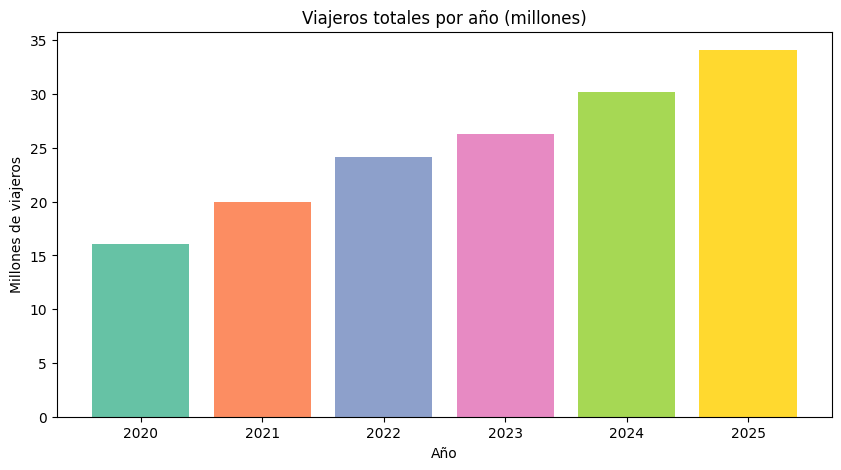

In [53]:
viajeros_anio = bizkaibus.groupby('ejercicio')['total'].sum() / 1_000_000

plt.figure(figsize=(10, 5))
bar_colors = sns.color_palette('Set2', n_colors=viajeros_anio.shape[0])
plt.bar(viajeros_anio.index.astype(str), viajeros_anio.values, color=bar_colors)
plt.title('Viajeros totales por año (millones)')
plt.xlabel('Año')
plt.ylabel('Millones de viajeros')
plt.show()


### 5.2 Top 15 Líneas por Total Histórico de Viajeros

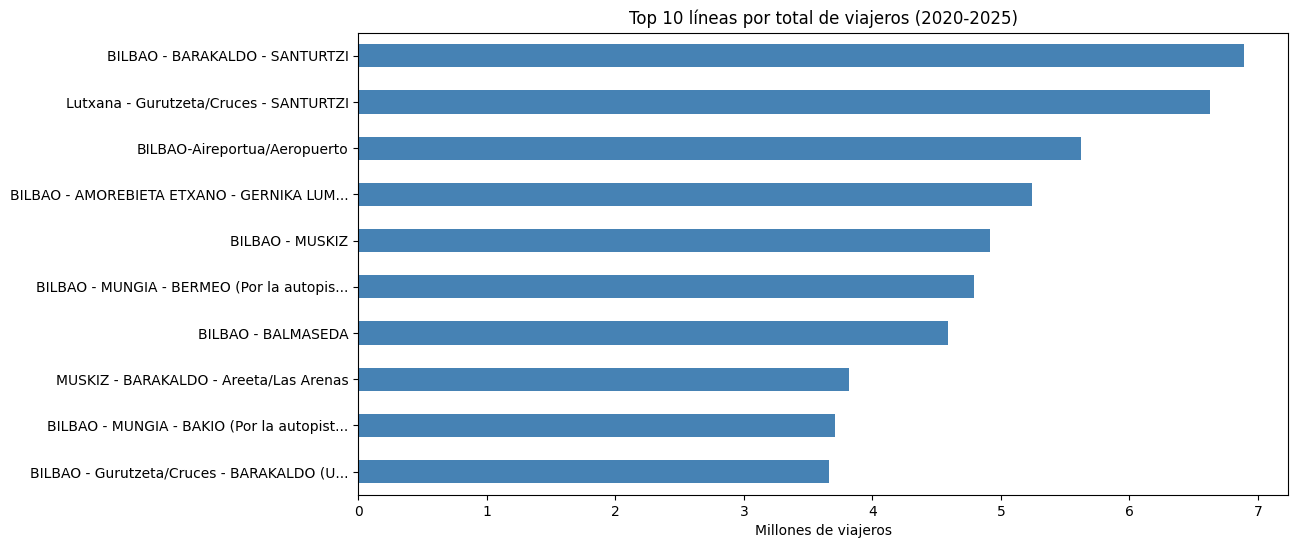

In [54]:
top_lineas = (bizkaibus_activo.groupby('linea')['total']
              .sum().sort_values(ascending=True).tail(10) / 1_000_000)

# Acortar nombres largos
top_lineas.index = [n[:40]+'...' if len(n) > 40 else n for n in top_lineas.index]

plt.figure(figsize=(12, 6))
top_lineas.plot.barh(color='steelblue')
plt.title('Top 10 líneas por total de viajeros (2020-2025)')
plt.xlabel('Millones de viajeros')
plt.show()


### 5.3 Distribución Total por Tipo de Título

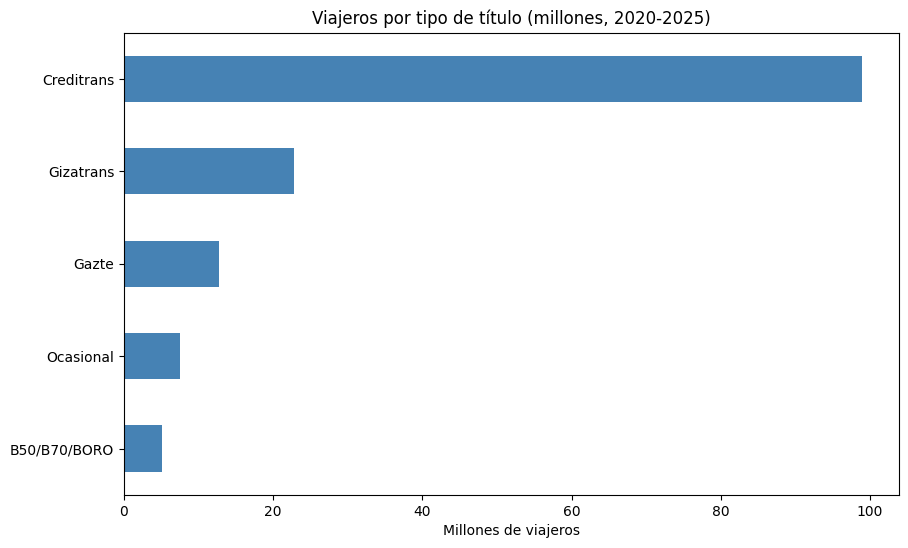

In [55]:
titulos = pd.Series({
    'Creditrans':      bizkaibus['creditrans'].sum(),
    'Gazte':        bizkaibus['gazte_70'].sum() + bizkaibus['goro'].sum(),
    'Gizatrans':       bizkaibus['gizatrans'].sum(),
    'B50/B70/BORO':    bizkaibus[['b50','b70','boro']].sum().sum(),
    'Ocasional':       bizkaibus['ocasional'].sum(),

}).sort_values() / 1_000_000

plt.figure(figsize=(10, 6))
titulos.plot.barh(color='steelblue')
plt.title('Viajeros por tipo de título (millones, 2020-2025)')
plt.xlabel('Millones de viajeros')
plt.show()


### 5.4 Estadísticos de Centralidad y Dispersión

In [56]:
t = bizkaibus_activo['total']

print("── Centralidad ──────────────────────────")
print(f"  Media      : {t.mean():>10,.0f}")
print(f"  Mediana    : {t.median():>10,.0f}")
print(f"  Moda       : {t.mode()[0]:>10,.0f}")
print(f"  Q1 (25%)   : {t.quantile(0.25):>10,.0f}")
print(f"  Q3 (75%)   : {t.quantile(0.75):>10,.0f}")
print(f"  P10        : {t.quantile(0.10):>10,.0f}")
print(f"  P90        : {t.quantile(0.90):>10,.0f}")
print()
print("── Dispersión ───────────────────────────")
print(f"  Varianza   : {t.var():>10,.0f}")
print(f"  Desv. std  : {t.std():>10,.0f}")
print(f"  Rango      : {t.max()-t.min():>10,.0f}")
print(f"  Mínimo     : {t.min():>10,.0f}")
print(f"  Máximo     : {t.max():>10,.0f}")
print(f"  Asimetría  : {t.skew():>10.2f}")


── Centralidad ──────────────────────────
  Media      :     23,035
  Mediana    :     14,806
  Moda       :          1
  Q1 (25%)   :      4,616
  Q3 (75%)   :     34,528
  P10        :        391
  P90        :     57,178

── Dispersión ───────────────────────────
  Varianza   : 618,762,014
  Desv. std  :     24,875
  Rango      :    159,803
  Mínimo     :          1
  Máximo     :    159,804
  Asimetría  :       1.71


### 5.5 Histograma y Boxplot de Viajeros por Línea-Mes

Skew: 1.71


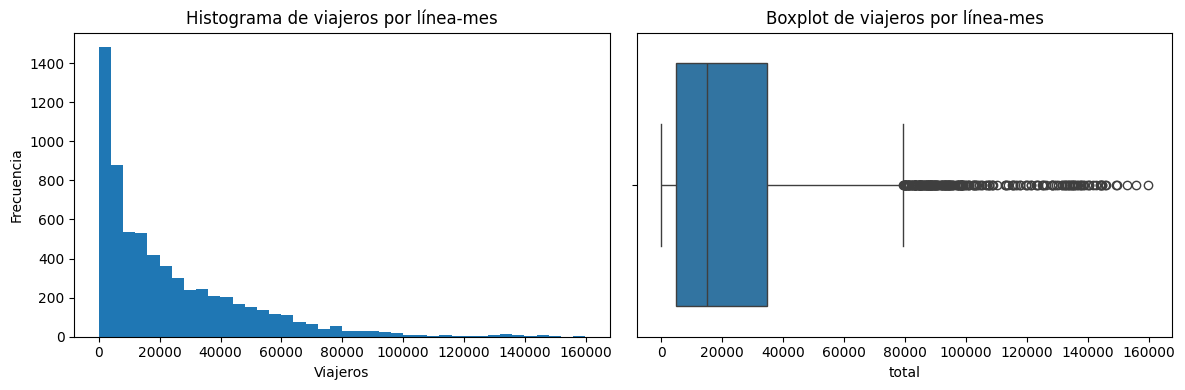

In [57]:
print('Skew:', round(bizkaibus_activo['total'].skew(), 2))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
bizkaibus_activo['total'].hist(grid=False, bins=40)
plt.xlabel('Viajeros')
plt.ylabel('Frecuencia')
plt.title('Histograma de viajeros por línea-mes')

plt.subplot(1, 2, 2)
sns.boxplot(x=bizkaibus_activo['total'])
plt.title('Boxplot de viajeros por línea-mes')

plt.tight_layout()
plt.show()


### 5.6 Violin Plot y Swarm Plot — Viajeros por Año

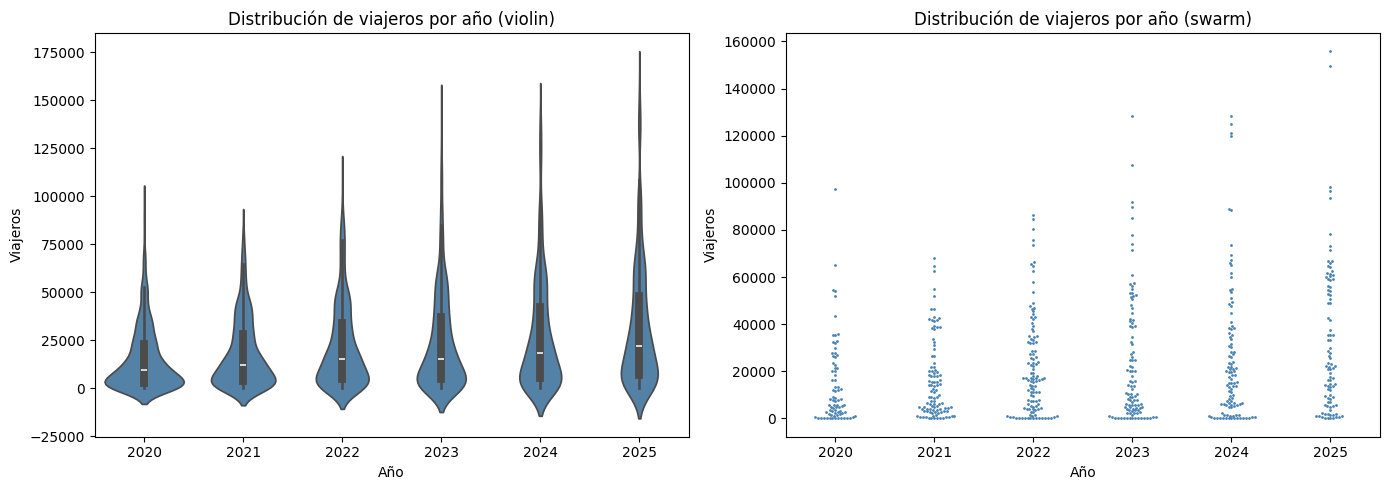

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=bizkaibus_activo, x='ejercicio', y='total', color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de viajeros por año (violin)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Viajeros')

# Swarm solo con muestra para no saturar
muestra = bizkaibus_activo.sample(min(600, len(bizkaibus_activo)), random_state=1)
sns.swarmplot(data=muestra, x='ejercicio', y='total', color='steelblue', size=2, ax=axes[1])
axes[1].set_title('Distribución de viajeros por año (swarm)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Viajeros')

plt.tight_layout()
plt.show()


### 5.7 Tabla de Frecuencias

           Registros     %
total                     
0-5k            1754  26.8
5k-20k          2093  32.0
20k-50k         1798  27.5
50k-100k         807  12.3
100k-500k         92   1.4
>500k              0   0.0



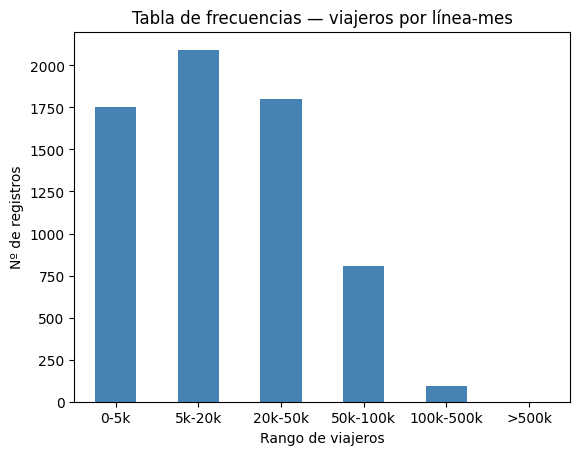

In [59]:
# Agrupamos en rangos de viajeros para ver cómo se distribuyen las líneas
max_total = bizkaibus_activo['total'].max()
upper_bin = max(500000, max_total) + 1
bins = [0, 5000, 20000, 50000, 100000, 500000, upper_bin]
etiquetas = ['0-5k', '5k-20k', '20k-50k', '50k-100k', '100k-500k', '>500k']

freq = pd.cut(bizkaibus_activo['total'], bins=bins, labels=etiquetas)
tabla = freq.value_counts().sort_index()
tabla_pct = (tabla / tabla.sum() * 100).round(1)

print(pd.DataFrame({'Registros': tabla, '%': tabla_pct}).to_string())
print()

tabla.plot.bar(color='steelblue', rot=0)
plt.title('Tabla de frecuencias — viajeros por línea-mes')
plt.xlabel('Rango de viajeros')
plt.ylabel('Nº de registros')
plt.show()


## 6. Análisis Bivariante

### 6.1 Heatmap de Viajeros por Año y Mes

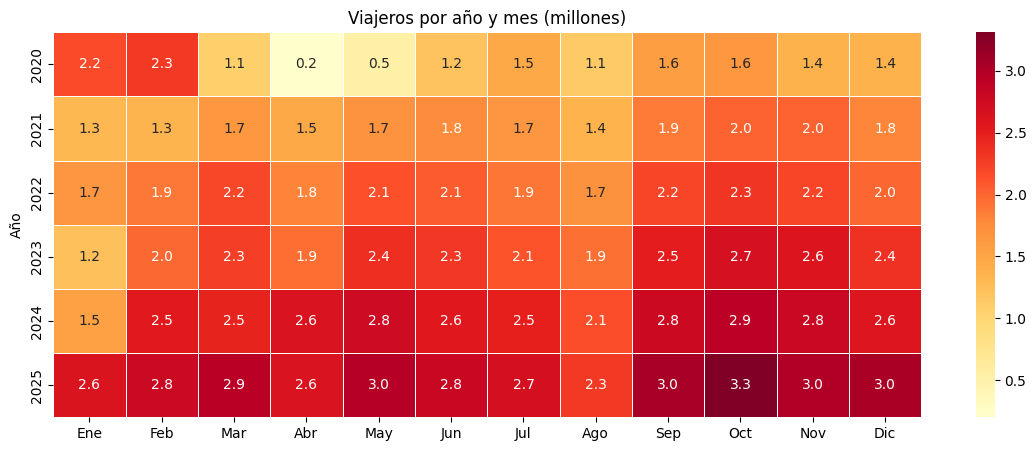

In [60]:
pivot = (bizkaibus.groupby(['ejercicio', 'mes'])['total']
          .sum().unstack(fill_value=0) / 1_000_000)
pivot.columns = [MESES_ES[m] for m in pivot.columns]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Viajeros por año y mes (millones)')
plt.ylabel('Año')
plt.show()


### 6.2 Evolución Temporal del Total de Viajeros

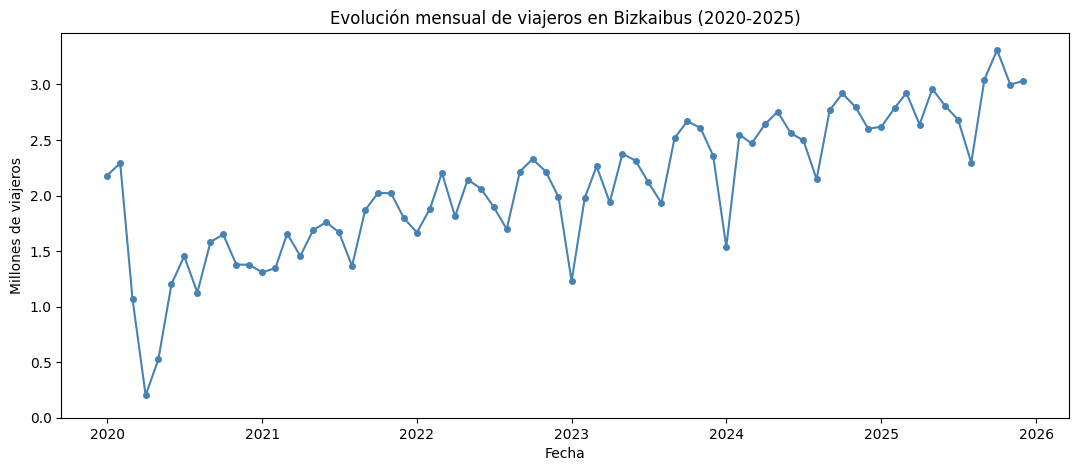

In [61]:
evolucion = bizkaibus.groupby('fecha')['total'].sum() / 1_000_000

plt.figure(figsize=(13, 5))
plt.plot(evolucion.index, evolucion.values, color='steelblue', marker='o', markersize=4)
plt.title('Evolución mensual de viajeros en Bizkaibus (2020-2025)')
plt.xlabel('Fecha')
plt.ylabel('Millones de viajeros')
plt.ylim(0)
plt.show()


### 6.3 Evolución por Tipo de Título (con punto de corte del subsidio)

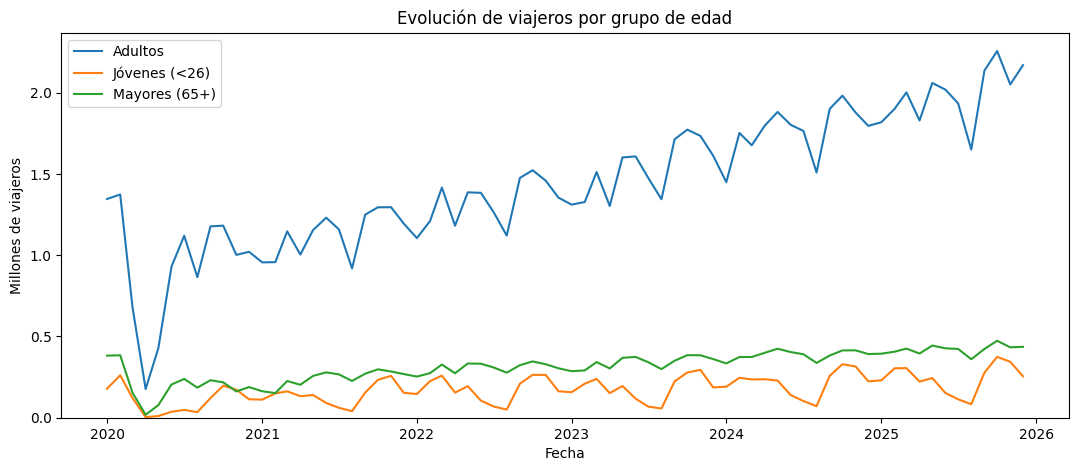

In [62]:
grupos = bizkaibus.groupby('fecha')[['jovenes','adultos','mayores']].sum() / 1_000_000

plt.figure(figsize=(13, 5))
plt.plot(grupos.index, grupos['adultos'], label='Adultos')
plt.plot(grupos.index, grupos['jovenes'], label='Jóvenes (<26)')
plt.plot(grupos.index, grupos['mayores'], label='Mayores (65+)')
plt.title('Evolución de viajeros por grupo de edad')
plt.xlabel('Fecha')
plt.ylabel('Millones de viajeros')
plt.ylim(0)
plt.legend()
plt.show()


### 6.4 Correlación entre Tipos de Título

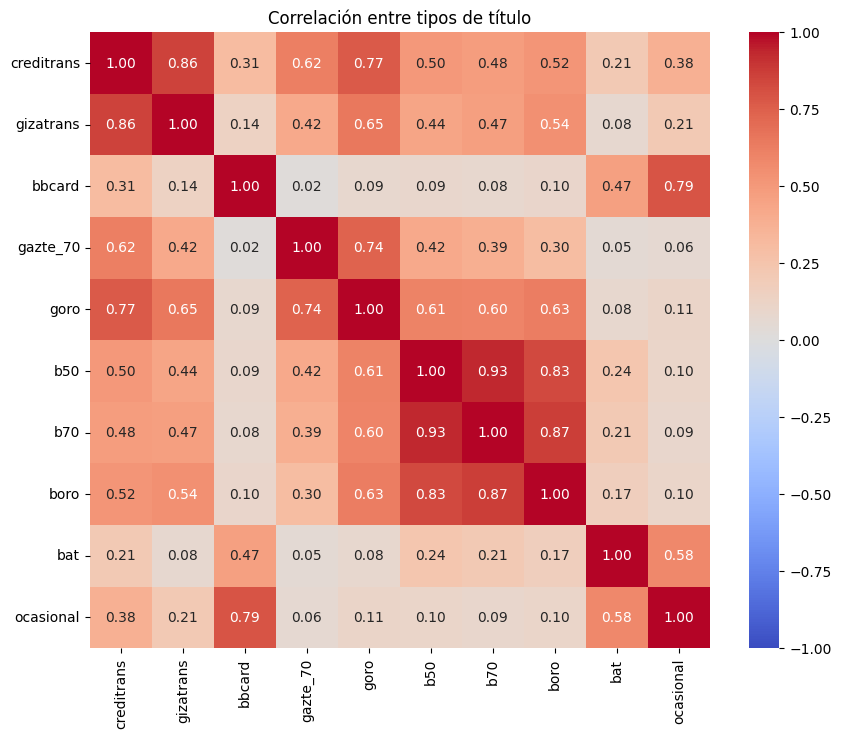

In [63]:
cols_titulos = ['creditrans','gizatrans','bbcard','gazte_70','goro','b50','b70','boro','bat','ocasional']

plt.figure(figsize=(10, 8))
sns.heatmap(bizkaibus[cols_titulos].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre tipos de título')
plt.show()


### 6.5 Líneas con Bilbao vs Sin Bilbao — Evolución Temporal

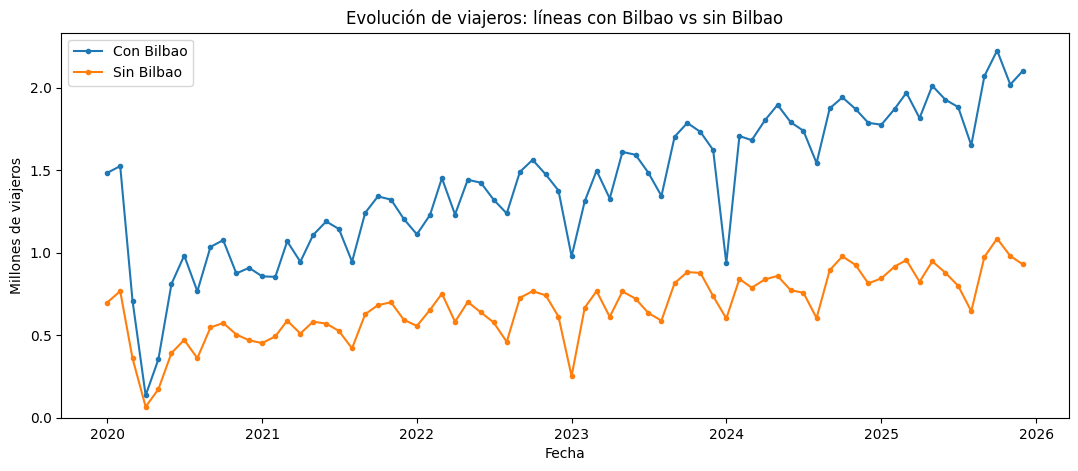

In [64]:
evol_bilbao = (bizkaibus_activo.groupby(['fecha','conecta_bilbao'])['total']
               .sum().reset_index())

plt.figure(figsize=(13, 5))
for flag, label in [(True, 'Con Bilbao'), (False, 'Sin Bilbao')]:
    sub = evol_bilbao[evol_bilbao['conecta_bilbao'] == flag]
    plt.plot(sub['fecha'], sub['total']/1e6, label=label, marker='o', markersize=3)

plt.title('Evolución de viajeros: líneas con Bilbao vs sin Bilbao')
plt.xlabel('Fecha')
plt.ylabel('Millones de viajeros')
plt.ylim(0)
plt.legend()
plt.show()


### 6.6 Agrupaciones — Estadísticos por Año y por Tipo de Línea

In [65]:
# Por año
print("── Viajeros por línea-mes, agrupado por AÑO ──")
print(bizkaibus_activo.groupby('ejercicio')['total'].describe().round().astype(int).to_string())
print()

# Por tipo de línea
print("── Viajeros por línea-mes, agrupado por CONECTA BILBAO ──")
print(bizkaibus_activo.groupby('conecta_bilbao')['total'].describe().round().astype(int).to_string())


── Viajeros por línea-mes, agrupado por AÑO ──
           count   mean    std  min   25%    50%    75%     max
ejercicio                                                      
2020        1065  15060  16371    1  2824   9289  22992   97423
2021        1097  18194  17886    1  4036  12373  28369   84483
2022        1099  21942  21710    1  4689  15328  33872  110187
2023        1103  23847  25073    1  4706  15364  37220  145608
2024        1100  27486  29034    1  5418  18161  42350  144555
2025        1080  31567  31640    2  6907  21900  47845  159804

── Viajeros por línea-mes, agrupado por CONECTA BILBAO ──
                count   mean    std  min    25%    50%    75%     max
conecta_bilbao                                                       
False            3322  14647  20715    1    894   6111  18739  146054
True             3222  31684  25828    1  12751  24790  43746  159804


### 6.7 Heatmap Líneas × Mes — Estacionalidad por Línea

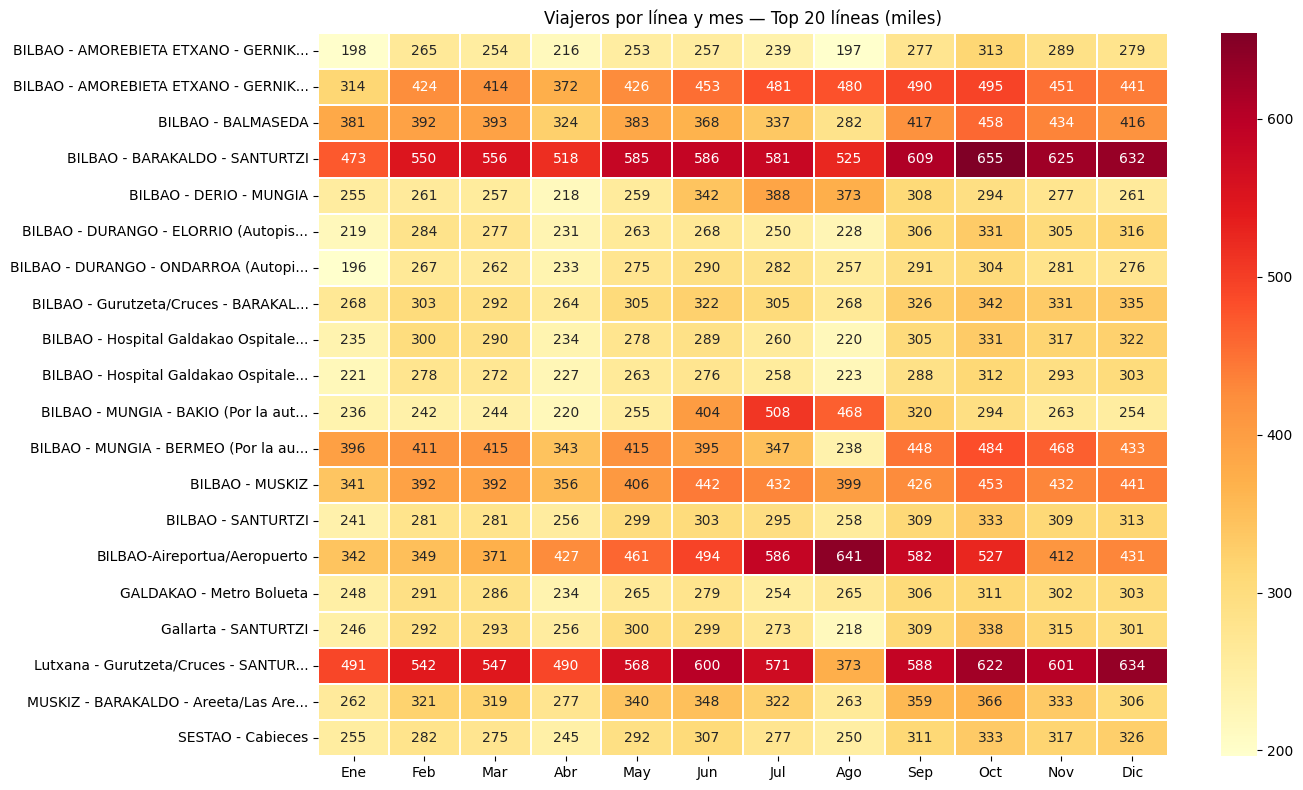

In [66]:
# Top 20 líneas por total de viajeros
top20 = (bizkaibus_activo.groupby('linea')['total'].sum()
         .sort_values(ascending=False).head(20).index)

pivot_lineas = (bizkaibus_activo[bizkaibus_activo['linea'].isin(top20)]
                .groupby(['linea', 'mes'])['total']
                .sum().unstack(fill_value=0) / 1_000)

pivot_lineas.columns = [MESES_ES[m] for m in pivot_lineas.columns]
pivot_lineas.index = [n[:35]+'...' if len(n) > 35 else n for n in pivot_lineas.index]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_lineas, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.3)
plt.title('Viajeros por línea y mes — Top 20 líneas (miles)')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


### 6.8 Scatter — Expediciones vs Viajeros (líneas activas vs saturadas)

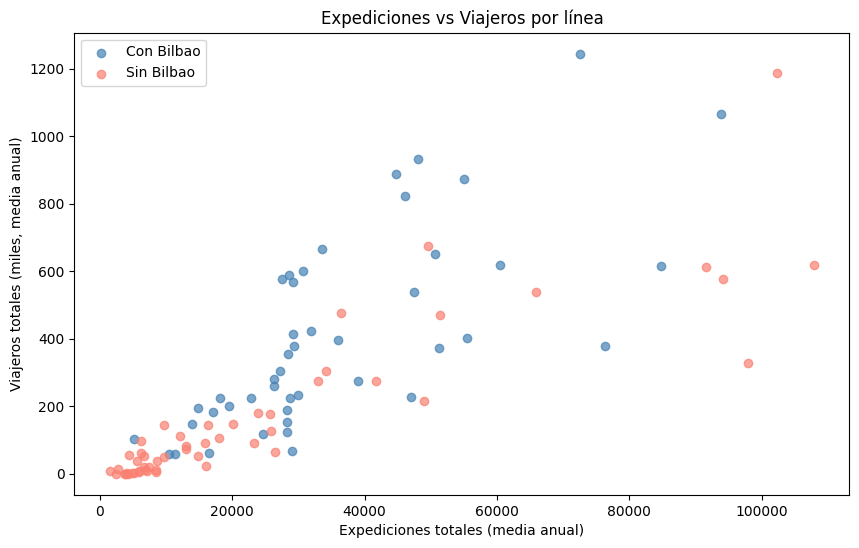

In [67]:
# Agrupamos saturacion por línea (media de todos los años)
sat_linea = saturacion.groupby(['linea', 'conecta_bilbao'])[
    ['total', 'total_expediciones', 'viajeros_por_exp']
].mean().reset_index()

plt.figure(figsize=(10, 6))
for flag, label, color in [(True, 'Con Bilbao', 'steelblue'), (False, 'Sin Bilbao', 'salmon')]:
    sub = sat_linea[sat_linea['conecta_bilbao'] == flag]
    plt.scatter(sub['total_expediciones'], sub['total'] / 1_000,
                label=label, color=color, alpha=0.7)

plt.title('Expediciones vs Viajeros por línea')
plt.xlabel('Expediciones totales (media anual)')
plt.ylabel('Viajeros totales (miles, media anual)')
plt.legend()
plt.show()
# Puntos arriba a la derecha = muchas exp Y muchos viajeros (líneas troncales)
# Puntos abajo a la derecha = muchas exp pero pocos viajeros (infrautilizadas)


## 7. Análisis Multivariante

### 7.1 Composición de Viajeros por Año (Stacked Bar por Grupo)

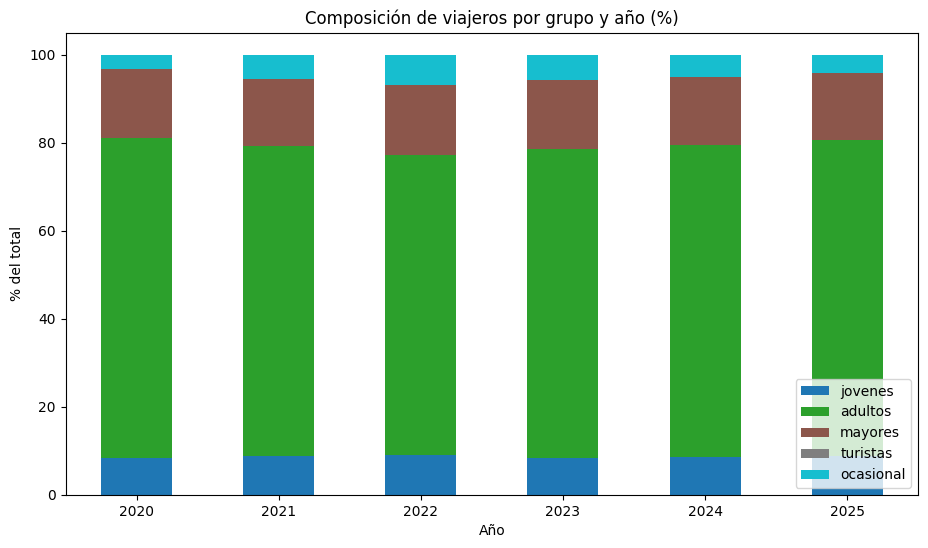

In [68]:
composicion = bizkaibus.groupby('ejercicio')[
    ['jovenes','adultos','mayores','turistas','ocasional']
].sum()
comp_pct = composicion.div(composicion.sum(axis=1), axis=0).mul(100)

comp_pct.plot.bar(stacked=True, figsize=(11, 6), colormap='tab10')
plt.title('Composición de viajeros por grupo y año (%)')
plt.xlabel('Año')
plt.ylabel('% del total')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()


### 7.2 Saturación por Línea — Top líneas más llenas (viajeros/expedición)


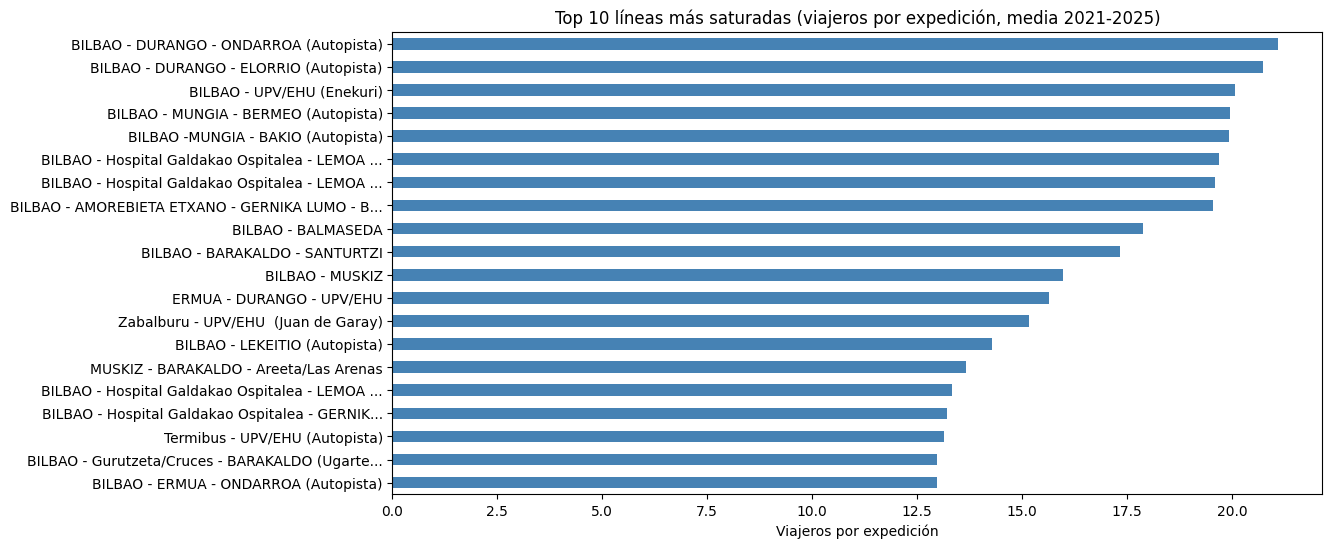

In [69]:
# Top 10 líneas más saturadas (media de todos los años disponibles)
top_sat = (saturacion.groupby('linea')['viajeros_por_exp']
           .mean().sort_values(ascending=True).tail(20))

top_sat.index = [n[:45]+'...' if len(n) > 45 else n for n in top_sat.index]

plt.figure(figsize=(12, 6))
top_sat.plot.barh(color='steelblue')
plt.title('Top 10 líneas más saturadas (viajeros por expedición, media 2021-2025)')
plt.xlabel('Viajeros por expedición')
plt.show()


### 7.3 Evolución de la Saturación por Año (Con Bilbao vs Sin Bilbao)


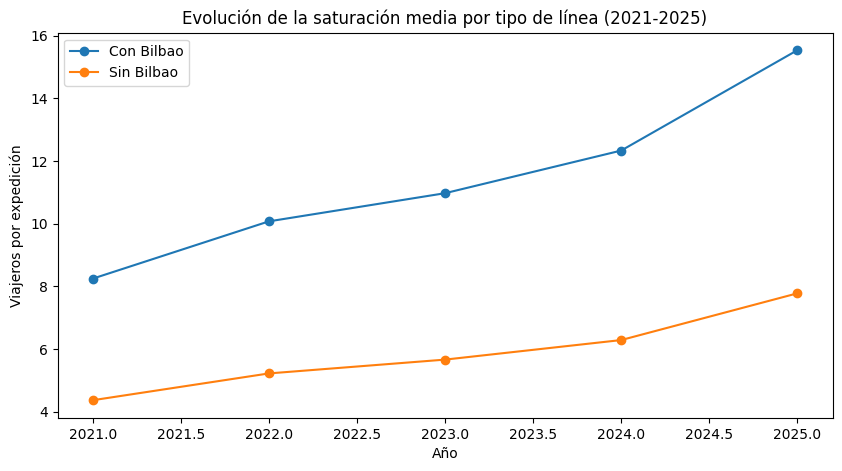

In [70]:
sat_anio = saturacion.groupby(['ejercicio', 'conecta_bilbao'])['viajeros_por_exp'].mean().reset_index()

plt.figure(figsize=(10, 5))
for flag, label in [(True, 'Con Bilbao'), (False, 'Sin Bilbao')]:
    sub = sat_anio[sat_anio['conecta_bilbao'] == flag]
    plt.plot(sub['ejercicio'], sub['viajeros_por_exp'], marker='o', label=label)

plt.title('Evolución de la saturación media por tipo de línea (2021-2025)')
plt.xlabel('Año')
plt.ylabel('Viajeros por expedición')
plt.legend()
plt.show()


### 7.4 Adopción de Nuevos Títulos Adultos (B50 / B70 / BORO) a lo largo del tiempo

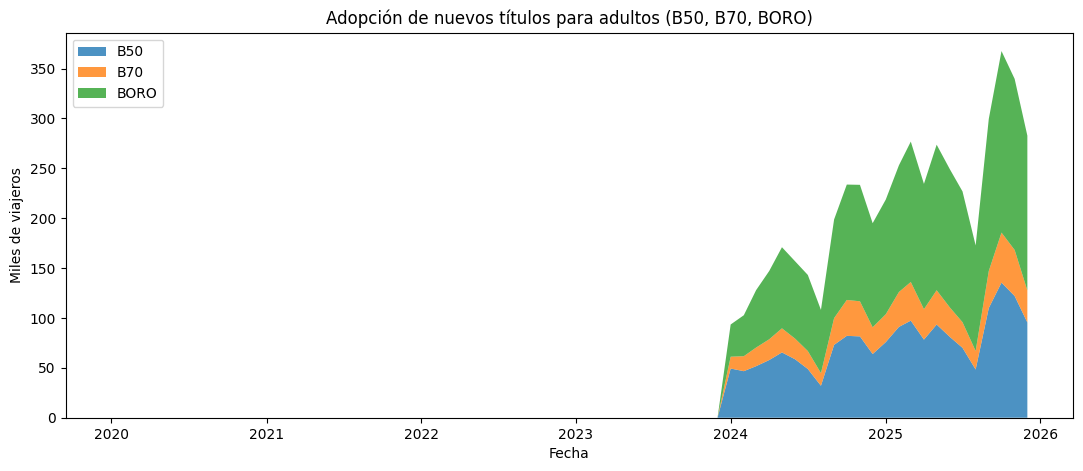

In [71]:
nuevos = bizkaibus.groupby('fecha')[['b50','b70','boro']].sum() / 1_000

plt.figure(figsize=(13, 5))
plt.stackplot(nuevos.index, nuevos['b50'], nuevos['b70'], nuevos['boro'],
              labels=['B50', 'B70', 'BORO'], alpha=0.8)
plt.title('Adopción de nuevos títulos para adultos (B50, B70, BORO)')
plt.xlabel('Fecha')
plt.ylabel('Miles de viajeros')
plt.ylim(0)
plt.legend(loc='upper left')
plt.show()


### 7.5 Distribución de uso de cada tipo de título

creditrans — Skew: 1.39


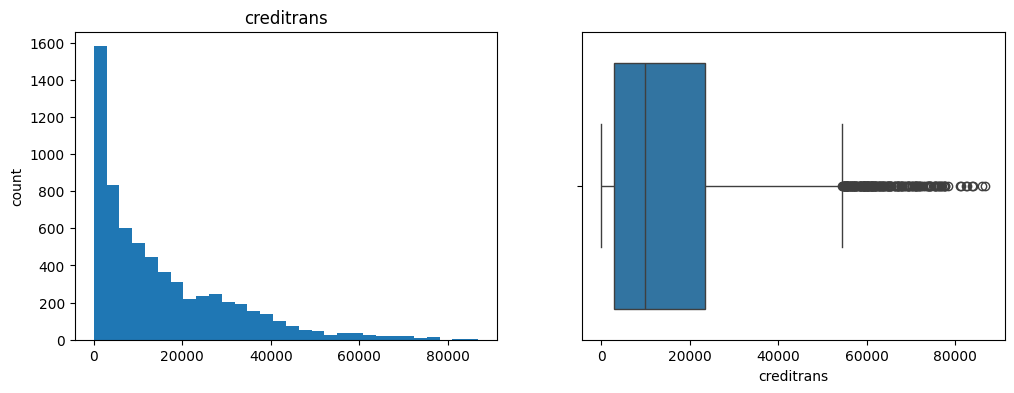

gizatrans — Skew: 1.85


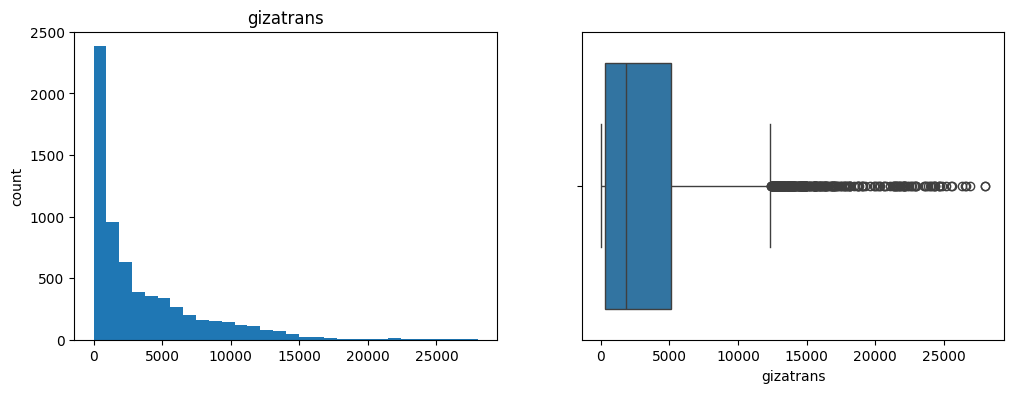

bbcard — Skew: 10.42


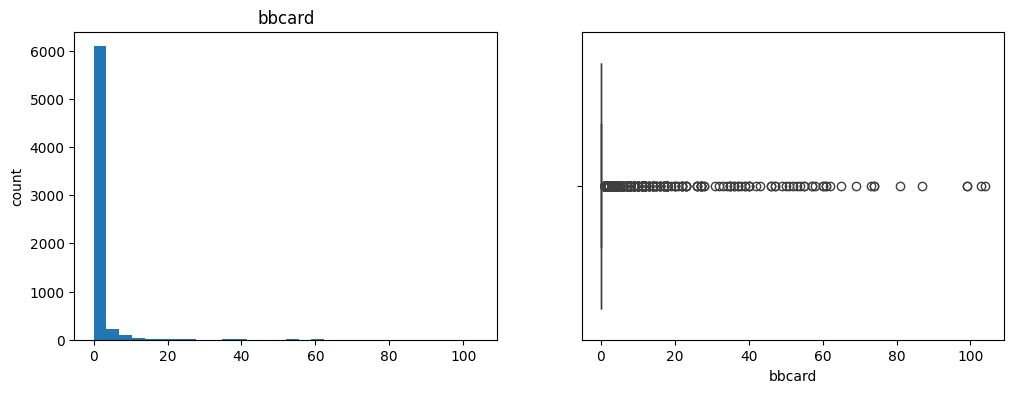

gazte_70 — Skew: 2.24


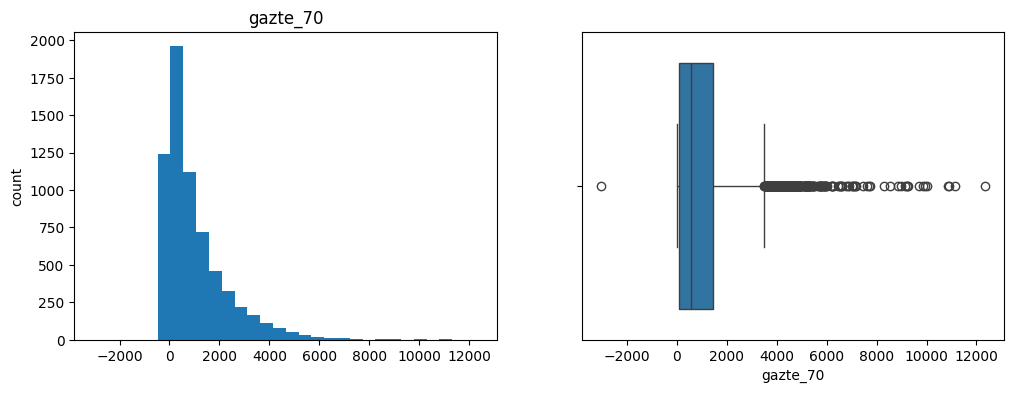

goro — Skew: 2.64


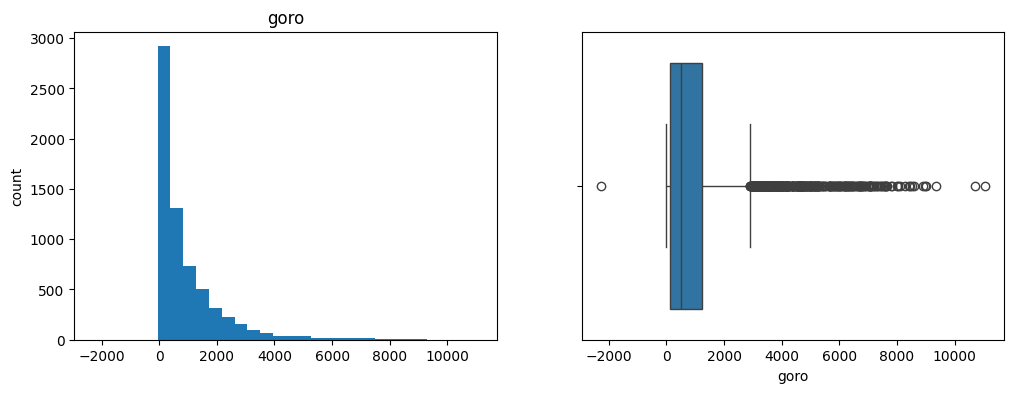

b50 — Skew: 4.45


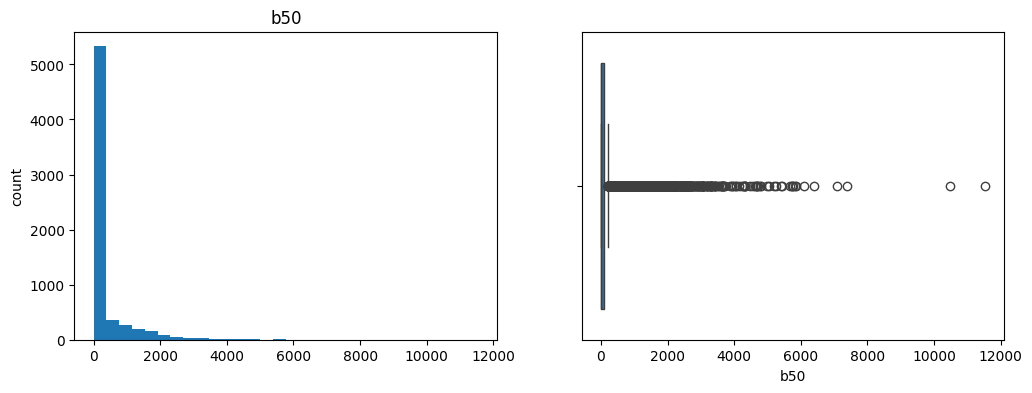

b70 — Skew: 4.94


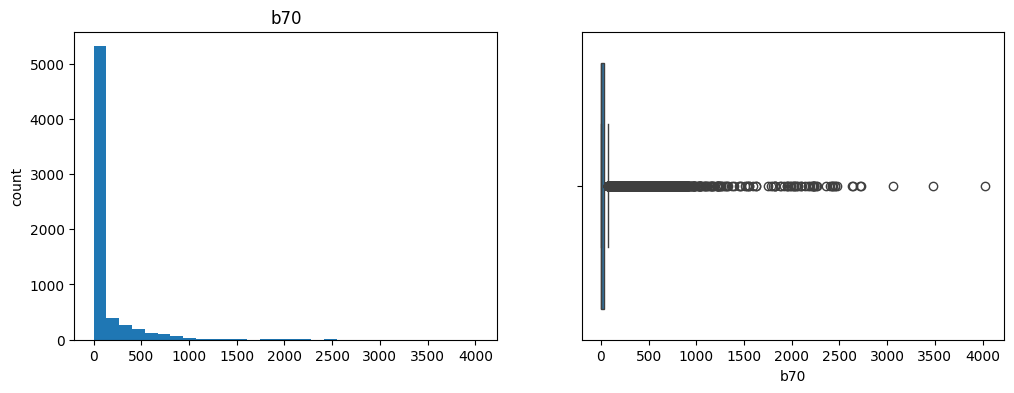

boro — Skew: 5.31


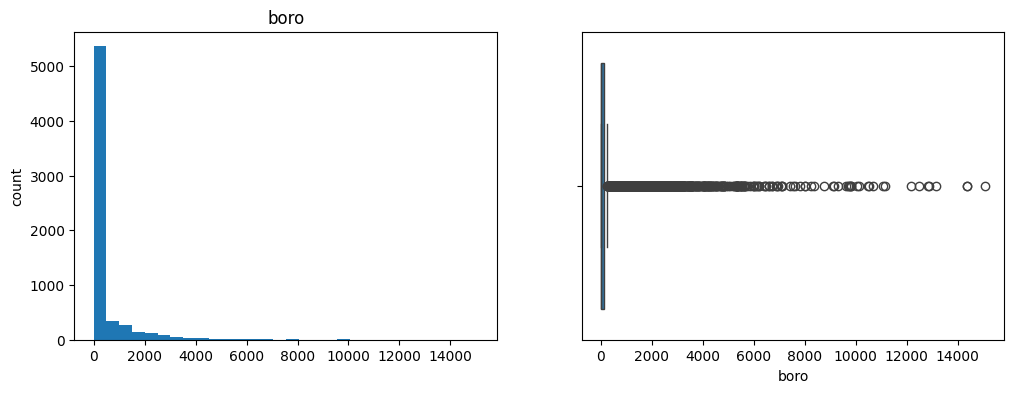

bat — Skew: 18.0


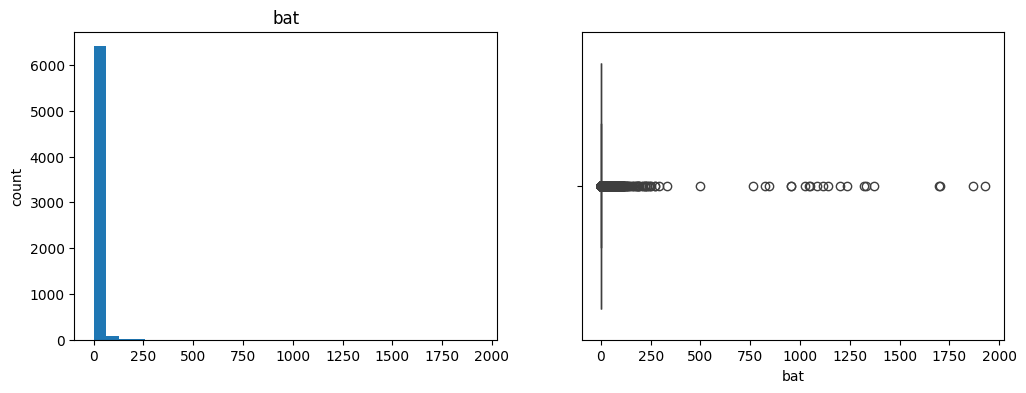

ocasional — Skew: 11.32


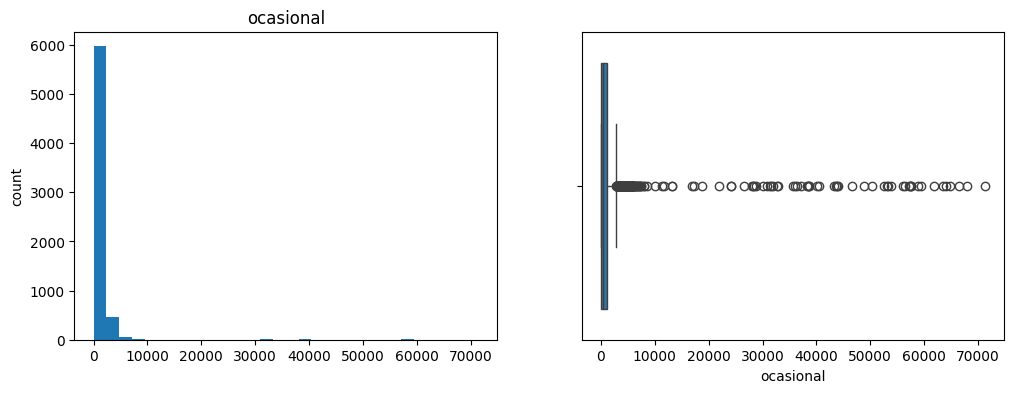

In [72]:
# Distribución de uso de cada tipo de título (histograma + boxplot)
cols_titulos = ['creditrans','gizatrans','bbcard','gazte_70','goro',
                'b50','b70','boro','bat','ocasional']

for col in cols_titulos:
    print(col, '— Skew:', round(bizkaibus_activo[col].skew(), 2))
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    bizkaibus_activo[col].hist(grid=False, bins=30)
    plt.ylabel('count')
    plt.title(col)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=bizkaibus_activo[col])
    plt.show()


### 7.5 Pairplot — Relación entre Tipos de Título

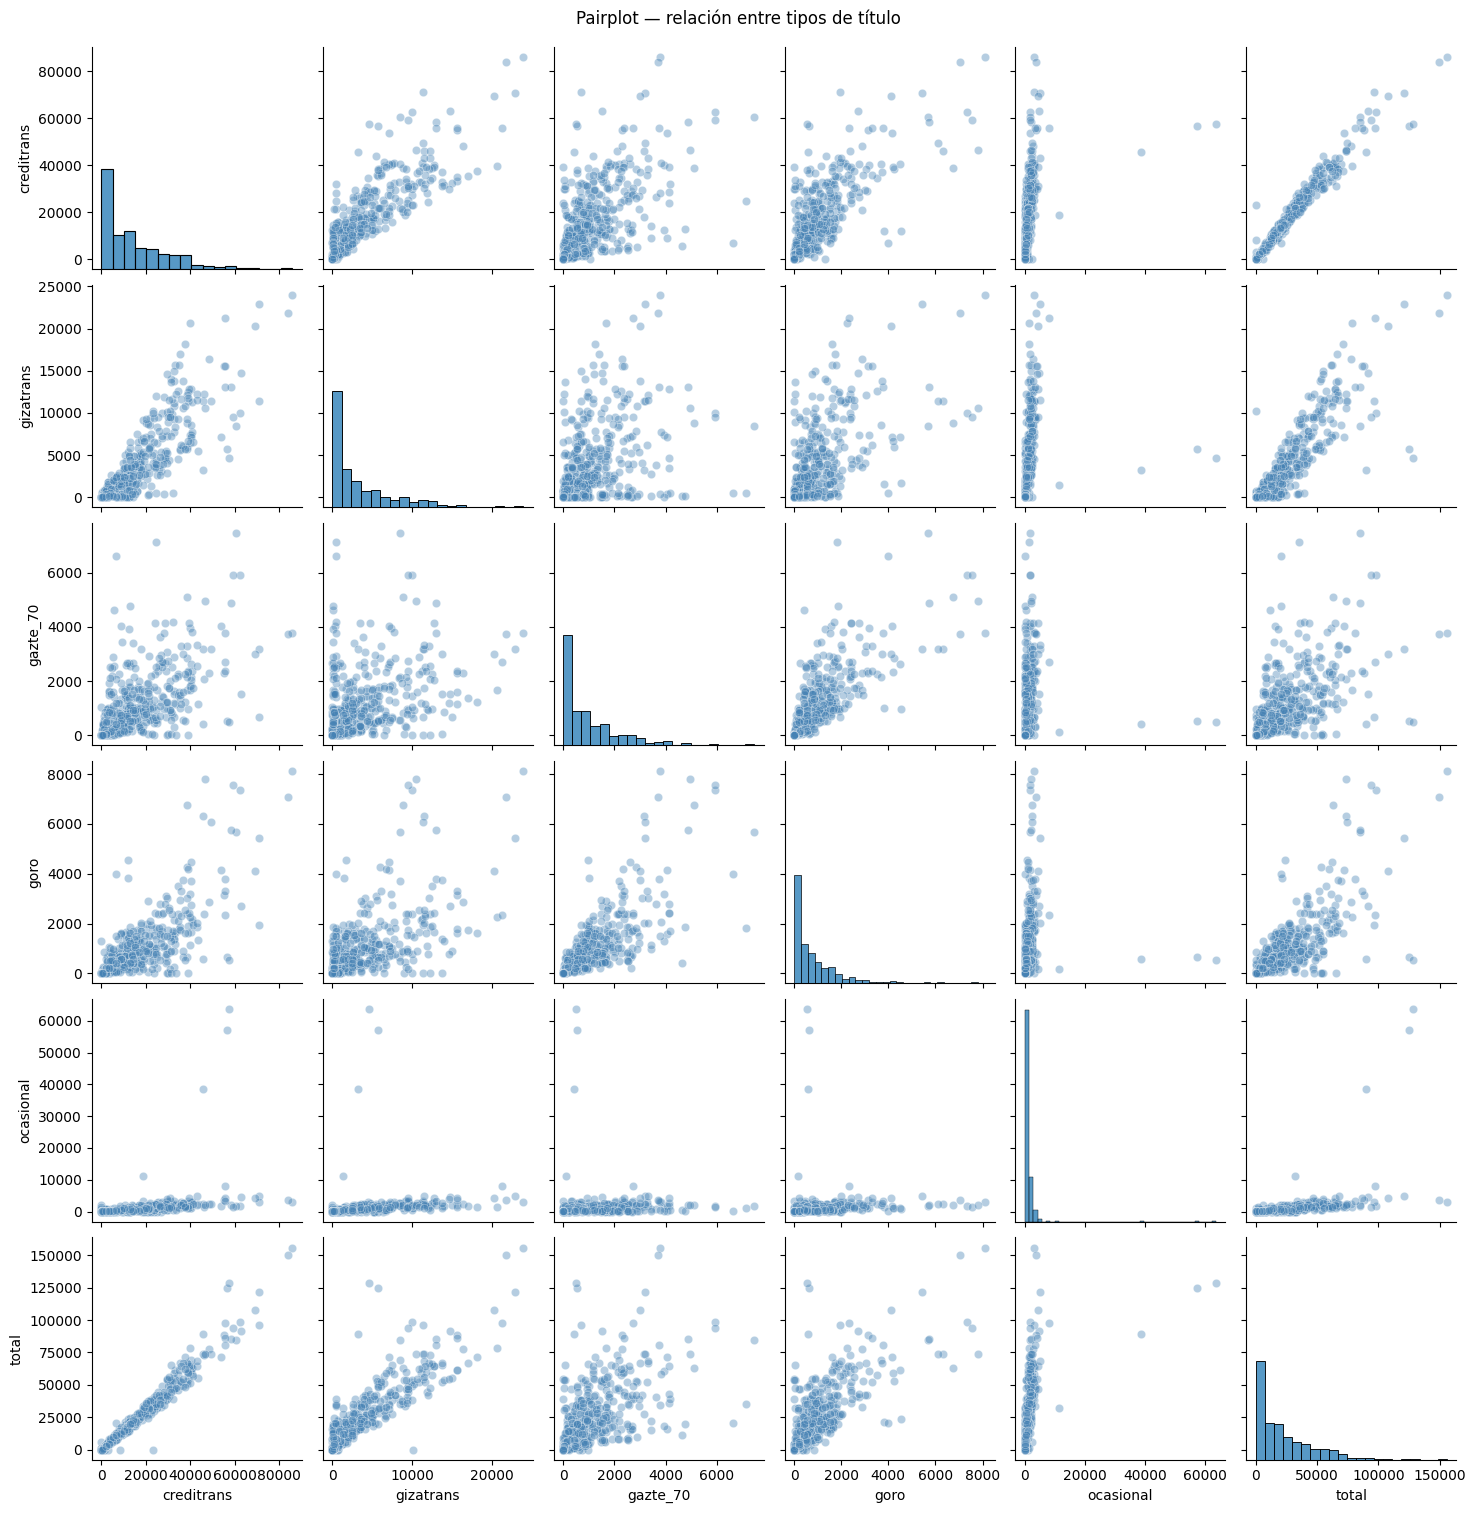

In [73]:
cols_pairplot = ['creditrans', 'gizatrans', 'gazte_70', 'goro', 'ocasional', 'total']

sns.pairplot(data=bizkaibus_activo[cols_pairplot].sample(500, random_state=1),
             diag_kind='hist', plot_kws={'alpha': 0.4, 'color': 'steelblue'})
plt.suptitle('Pairplot — relación entre tipos de título', y=1.01)
plt.show()


## 8. Contraste de Hipótesis

### H1 — *"Los títulos bonificados para jóvenes representan una proporción significativa del total de viajeros"*

Consideramos "significativa" si los viajeros jóvenes (`gazte_70 + goro`) superan el **15% del total**.


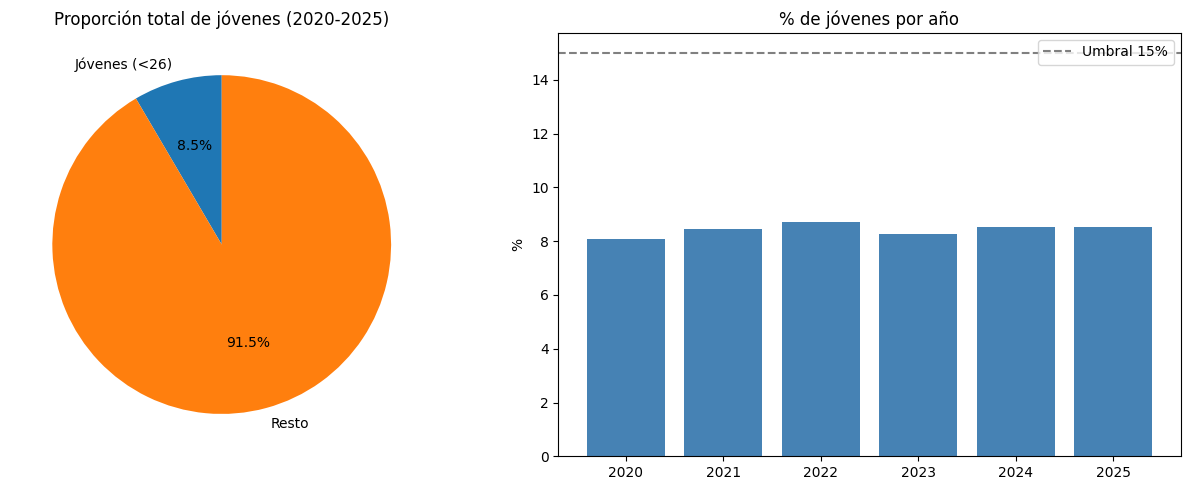

Proporción de jóvenes: 8.5%  (umbral: 15%)
H1 → ❌ NO CONFIRMADA


In [74]:
jovenes_total = bizkaibus['jovenes'].sum()
gran_total    = bizkaibus['total'].sum()
pct_jovenes   = jovenes_total / gran_total * 100

prop_anio = (bizkaibus.groupby('ejercicio')
               .apply(lambda x: x['jovenes'].sum() / x['total'].sum() * 100)
               .reset_index(name='pct'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([pct_jovenes, 100 - pct_jovenes],
            labels=['Jóvenes (<26)', 'Resto'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Proporción total de jóvenes (2020-2025)')

axes[1].bar(prop_anio['ejercicio'].astype(str), prop_anio['pct'], color='steelblue')
axes[1].axhline(15, color='gray', linestyle='--', label='Umbral 15%')
axes[1].set_title('% de jóvenes por año')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

UMBRAL_H1 = 15
veredicto_H1 = "✅ CONFIRMADA" if pct_jovenes >= UMBRAL_H1 else "❌ NO CONFIRMADA"
print(f"Proporción de jóvenes: {pct_jovenes:.1f}%  (umbral: {UMBRAL_H1}%)")
print(f"H1 → {veredicto_H1}")


### H2 — *"Hay meses con más afluencia que otros"*

Medimos la variabilidad entre meses con el **coeficiente de variación (CV)**.  
Si CV > 10% consideramos que la estacionalidad mensual es notable.


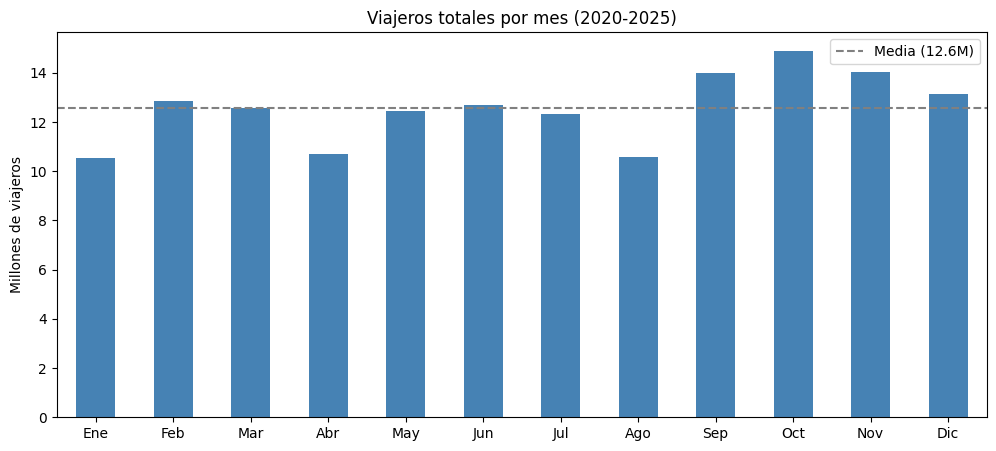

Coeficiente de variación entre meses: 11.2%
H2 → ✅ CONFIRMADA


In [75]:
viajeros_mes = bizkaibus.groupby('mes')['total'].sum() / 1_000_000
vm_ord = pd.Series([viajeros_mes.get(m, 0) for m in range(1,13)],
                   index=list(MESES_ES.values()))

cv = vm_ord.std() / vm_ord.mean() * 100

plt.figure(figsize=(12, 5))
vm_ord.plot.bar(color='steelblue', rot=0)
plt.axhline(vm_ord.mean(), color='gray', linestyle='--', label=f'Media ({vm_ord.mean():.1f}M)')
plt.title('Viajeros totales por mes (2020-2025)')
plt.ylabel('Millones de viajeros')
plt.legend()
plt.show()

veredicto_H2 = "✅ CONFIRMADA" if cv > 10 else "⚠️ DÉBIL"
print(f"Coeficiente de variación entre meses: {cv:.1f}%")
print(f"H2 → {veredicto_H2}")


### H3 — *"Las líneas que conectan con Bilbao son las más saturadas"*

Medimos la **saturación** como el número de viajeros por expedición realizada.  
Si las líneas con Bilbao tienen más viajeros por expedición, van más llenas → están más saturadas.


Viajeros medios por expedición:
  Con Bilbao:  11.4
  Sin Bilbao:  5.9


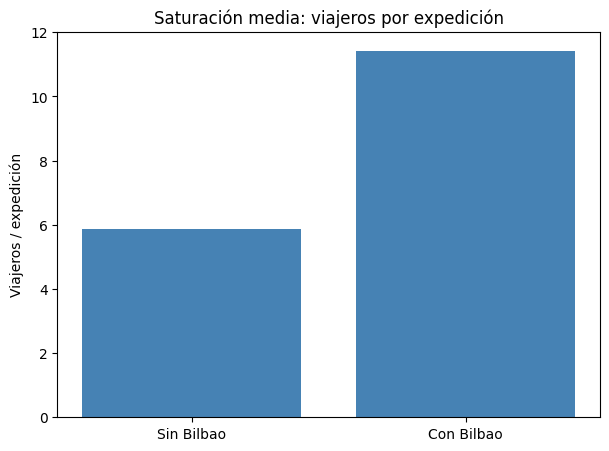

H3 → ✅ CONFIRMADA


In [76]:
# Saturación media por tipo de línea (Con Bilbao vs Sin Bilbao)
media_sat = saturacion.groupby('conecta_bilbao')['viajeros_por_exp'].mean()
print("Viajeros medios por expedición:")
print(f"  Con Bilbao:  {media_sat.get(True, 0):.1f}")
print(f"  Sin Bilbao:  {media_sat.get(False, 0):.1f}")

plt.figure(figsize=(7, 5))
plt.bar(['Sin Bilbao', 'Con Bilbao'],
        [media_sat.get(False, 0), media_sat.get(True, 0)],
        color='steelblue')
plt.title('Saturación media: viajeros por expedición')
plt.ylabel('Viajeros / expedición')
plt.show()

veredicto_H3 = "✅ CONFIRMADA" if media_sat.get(True, 0) > media_sat.get(False, 0) else "❌ NO CONFIRMADA"
print(f"H3 → {veredicto_H3}")


### H4 — *"Las ayudas al transporte han impulsado el uso del autobús"*

Comparamos la **media mensual de viajeros** antes y después del subsidio del 50%.

> ⚠️ **Nota metodológica:** 2020 estuvo afectado por el COVID-19, lo que deprime el baseline.  
> Para un análisis más robusto comparamos también el período 2021-ago 2022 (sin COVID) contra sep 2022-2025.


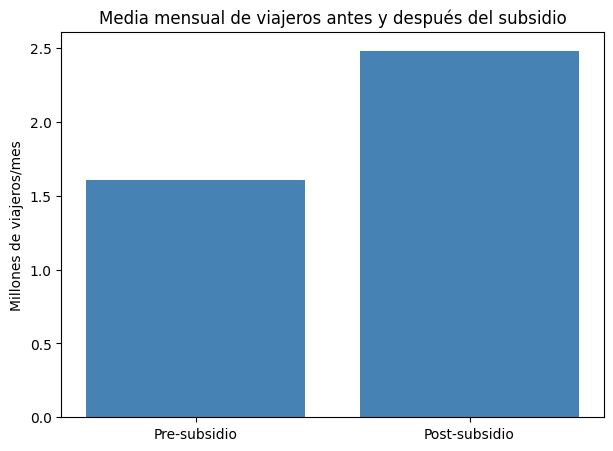

Media pre-subsidio:  1.61M viajeros/mes
Media post-subsidio: 2.48M viajeros/mes
Variación: +54.8%
H4 → ✅ CONFIRMADA

Nota: el período pre incluye 2020 (COVID), que baja la media artificialmente.


In [77]:
SUBSIDIO_INICIO = pd.Timestamp('2022-09-01')

media_periodo = (bizkaibus.groupby(['fecha','periodo_subsidio'])['total']
                 .sum().reset_index()
                 .groupby('periodo_subsidio')['total'].mean())

media_pre  = media_periodo.get('Pre-subsidio (<Sep 2022)',  0) / 1_000_000
media_post = media_periodo.get('Post-subsidio (>=Sep 2022)', 0) / 1_000_000
incremento = (media_post - media_pre) / media_pre * 100

plt.figure(figsize=(7, 5))
plt.bar(['Pre-subsidio', 'Post-subsidio'], [media_pre, media_post], color='steelblue')
plt.title('Media mensual de viajeros antes y después del subsidio')
plt.ylabel('Millones de viajeros/mes')
plt.show()

veredicto_H4 = "✅ CONFIRMADA" if incremento > 5 else "⚠️ DÉBIL"
print(f"Media pre-subsidio:  {media_pre:.2f}M viajeros/mes")
print(f"Media post-subsidio: {media_post:.2f}M viajeros/mes")
print(f"Variación: +{incremento:.1f}%")
print(f"H4 → {veredicto_H4}")
print()
print("Nota: el período pre incluye 2020 (COVID), que baja la media artificialmente.")


## 9. Resumen de Hipótesis y Conclusiones

### Tabla resumen

| # | Hipótesis | Métrica clave | Veredicto |
|---|-----------|---------------|-----------|
| H1 | Títulos jóvenes = proporción significativa | % viajeros jóvenes ≥ 15% | Ver H1 |
| H2 | Estacionalidad mensual notable | Coeficiente de variación > 10% | Ver H2 |
| H3 | Líneas con Bilbao más saturadas | Viajeros/expedición con vs sin Bilbao | Ver H3 |
| H4 | El subsidio impulsó el uso del bus | Media mensual post > pre | Ver H4 |
